# Aktualisierung der IJAL-Kostenanalyse für Deutschland, Polen und Tschechien

Diese Analyse aktualisiert die Ergebnisse aus:

> Kotsios & Folinas (2020): *Analysis and Comparison of Road Freight Transport Cost in 20 European Countries*. International Journal of Applied Logistics, Vol. 10, Issue 1.

Das Paper analysiert vier Kostenpositionen für Straßengüterverkehr (per 100 km auf der Autobahn, 5-achsiger Mercedes Actros):

| Kostenposition | Methodik |
|---|---|
| **Kraftstoff** | Dieselpreis (€/L) × 26,5 L/100km |
| **Fahrerkosten** | Mindestlohn (€/h) × 1,25 h/100km (bei 80 km/h) |
| **Maut** | Länderspezifisch (Hauptstrecke je Land) |
| **Reifen** | Preis für 10 Reifen / 120.000 km Laufleistung × 100 |

**Baseline-Daten (20. Juli 2018, €/100km)**

| Land | Kraftstoff | Fahrer | Maut | Reifen | Total |
|------|-----------|--------|------|--------|-------|
| Deutschland | 34.45 | 11.05 | 15.60 | 5.29 | 66.38 |
| Polen | 29.95 | 3.96 | 6.27 | 5.67 | 45.85 |
| Tschechien | 33.39 | 3.53 | 18.24 | 5.18 | 60.33 |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

COUNTRIES = ["Germany", "Poland", "Czechia"]
COUNTRY_LABELS = {"Germany": "Deutschland", "Poland": "Polen", "Czechia": "Tschechien"}
FUEL_CONSUMPTION_L_PER_100KM = 26.5
HOURS_PER_100KM = 1.25
TYRE_COUNT = 10
TYRE_DURATION_KM = 120_000

## 1. Kraftstoffpreise — EU Weekly Oil Bulletin (Historische Daten)

Die EU-Kommission stellt eine vollständige Preishistorie als Excel-Datei bereit:
[Weekly Oil Bulletin](https://energy.ec.europa.eu/data-and-analysis/weekly-oil-bulletin_en)

Die lokale Datei `Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx` enthält Wochendaten ab 2005. Sheet `Prices with taxes`, Preise in €/1000 L.

Relevante Spalten:
- `DE_price_with_tax_diesel` — Deutschland
- `PL_price_with_tax_diesel` — Polen
- `CZ_price_with_tax_diesel` — Tschechien

In [2]:
xl = pd.ExcelFile("Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx")

# Row 0 = column IDs, rows 1+2 = product name and unit (skip)
df_raw = xl.parse("Prices with taxes", header=0, skiprows=[1, 2])

date_col = df_raw.columns[0]
df_raw[date_col] = pd.to_datetime(df_raw[date_col], errors="coerce")
df_raw = df_raw.dropna(subset=[date_col]).set_index(date_col).sort_index()
df_raw.index.name = "date"

diesel_cols = {
    "Germany": "DE_price_with_tax_diesel",
    "Poland":  "PL_price_with_tax_diesel",
    "Czechia": "CZ_price_with_tax_diesel",
}
df_fuel = df_raw[list(diesel_cols.values())].rename(columns={v: k for k, v in diesel_cols.items()})
df_fuel = df_fuel.apply(pd.to_numeric, errors="coerce") / 1000  # €/1000 L → €/L

print(f"Datenzeitraum: {df_fuel.index.min().date()} bis {df_fuel.index.max().date()}")
print(f"\nAktuellste Woche ({df_fuel.index.max().date()}):")
print(df_fuel.tail(1).T.rename(columns={df_fuel.index.max(): "€/L"}))

Datenzeitraum: 2005-01-03 bis 2026-05-11

Aktuellste Woche (2026-05-11):
date          €/L
Germany  1.970000
Poland   1.623314
Czechia  1.750462


In [3]:
# Baseline-Woche Juli 2018 und aktuellste Woche
row_2018 = df_fuel.loc["2018-07-16":"2018-07-23"].iloc[0]
row_current = df_fuel.iloc[-1]
current_date = df_fuel.index[-1].strftime("%Y-%m-%d")

fuel_costs_2018    = {c: row_2018[c]    * FUEL_CONSUMPTION_L_PER_100KM for c in COUNTRIES}
fuel_costs_current = {c: row_current[c] * FUEL_CONSUMPTION_L_PER_100KM for c in COUNTRIES}

print(f"Kraftstoffkosten €/100km (Dieselpreis × {FUEL_CONSUMPTION_L_PER_100KM} L):")
print(f"{'Land':<15} {'2018':>8} {current_date[:7]:>10} {'Δ':>8}")
for c in COUNTRIES:
    chg = (fuel_costs_current[c] - fuel_costs_2018[c]) / fuel_costs_2018[c] * 100
    print(f"{COUNTRY_LABELS[c]:<15} {fuel_costs_2018[c]:>7.2f}€  {fuel_costs_current[c]:>8.2f}€  {chg:>+7.1f}%")

Kraftstoffkosten €/100km (Dieselpreis × 26.5 L):
Land                2018    2026-05        Δ
Deutschland       33.71€     52.20€    +54.9%
Polen             31.10€     43.02€    +38.3%
Tschechien        33.19€     46.39€    +39.7%


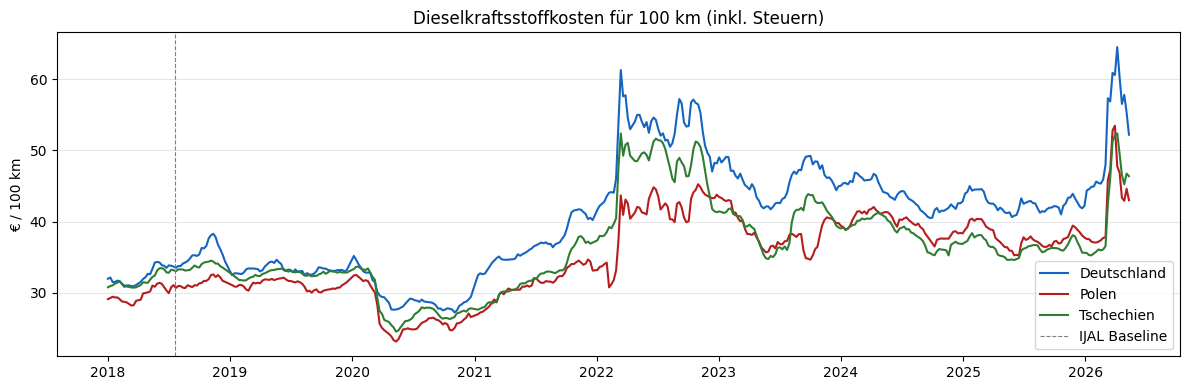

In [4]:
# Zeitreihe der Kraftstoffkosten (2018 bis heute)
fuel_plot = df_fuel["2018":] * FUEL_CONSUMPTION_L_PER_100KM

fig, ax = plt.subplots(figsize=(12, 4))
for country, color in zip(COUNTRIES, ["#1565C0", "#B71C1C", "#2E7D32"]):
    ax.plot(fuel_plot.index, fuel_plot[country], label=COUNTRY_LABELS[country], color=color)
ax.axvline(pd.Timestamp("2018-07-20"), color="gray", linestyle="--", linewidth=0.8, label="IJAL Baseline")
ax.set_ylabel("€ / 100 km")
ax.set_title("Dieselkraftsstoffkosten für 100 km (inkl. Steuern)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Fahrerkosten — Mindestlöhne 2025

Seit 2018 sind die gesetzlichen Mindestlöhne in allen drei Ländern erheblich gestiegen.

| Land | Quelle | Mindestlohn 2025 |
|------|--------|------------------|
| Deutschland | BMAS (ab 01.01.2025) | 12,82 €/h |
| Polen | MRPiPS (ab 01.01.2025) | 30,50 PLN/h |
| Tschechien | MPSV (ab 01.01.2025) | 103,80 CZK/h |

ECB-Referenzkurse Mai 2025: 1 EUR = 4,26 PLN · 1 EUR = 25,05 CZK

In [5]:
min_wage_eur_per_hour = {
    "Germany": 12.82,
    "Poland":  30.50 / 4.26,
    "Czechia": 103.80 / 25.05,
}
min_wage_2018 = {"Germany": 8.84, "Poland": 3.17, "Czechia": 2.82}

driver_costs         = {c: min_wage_eur_per_hour[c] * HOURS_PER_100KM for c in COUNTRIES}
driver_costs_2018    = {c: min_wage_2018[c]         * HOURS_PER_100KM for c in COUNTRIES}

print(f"{'Land':<15} {'Lohn 2018':>10} {'Kosten 2018':>13} {'Lohn 2025':>10} {'Kosten 2025':>13} {'Δ':>8}")
for c in COUNTRIES:
    w18, w25 = min_wage_2018[c], min_wage_eur_per_hour[c]
    k18, k25 = driver_costs_2018[c], driver_costs[c]
    print(f"{COUNTRY_LABELS[c]:<15} {w18:>9.2f}€  {k18:>11.2f}€  {w25:>9.2f}€  {k25:>11.2f}€  {(k25-k18)/k18*100:>+7.1f}%")

Land             Lohn 2018   Kosten 2018  Lohn 2025   Kosten 2025        Δ
Deutschland          8.84€        11.05€      12.82€        16.02€    +45.0%
Polen                3.17€         3.96€       7.16€         8.95€   +125.9%
Tschechien           2.82€         3.52€       4.14€         5.18€    +46.9%


## 3. Mautkosten 2025

| Land | Strecke | 2018 | 2025 | Änderung |
|------|---------|------|------|----------|
| **Deutschland** | Berlin–Hamburg (287 km) | 15,60 €/100km | ~35,00 €/100km | CO₂-Aufschlag ab Dez. 2023 ([toll-collect.de](https://www.toll-collect.de)) |
| **Polen** | Warschau–Krakau (360 km) | 6,27 €/100km | ~7,80 €/100km | e-TOLL-System ([etoll.gov.pl](https://etoll.gov.pl)) |
| **Tschechien** | Prag–Brünn (186 km) | 18,24 €/100km | ~20,43 €/100km | Neues elektronisches System ([mytocz.eu](https://mytocz.eu)) |

In [6]:
tolls_current = {"Germany": 35.00, "Poland": 7.80, "Czechia": 20.43}
tolls_2018    = {"Germany": 15.60, "Poland": 6.27, "Czechia": 18.24}

for c in COUNTRIES:
    chg = (tolls_current[c] - tolls_2018[c]) / tolls_2018[c] * 100
    print(f"{COUNTRY_LABELS[c]}: {tolls_2018[c]:.2f} → {tolls_current[c]:.2f} €/100km ({chg:+.1f}%)")

Deutschland: 15.60 → 35.00 €/100km (+124.4%)
Polen: 6.27 → 7.80 €/100km (+24.4%)
Tschechien: 18.24 → 20.43 €/100km (+12.0%)


## 4. Reifenkosten 2025

10 Reifen 295/60R22.5, Laufleistung 120.000 km. Preise moderat gestiegen (Inflation, Rohstoffkosten).

In [7]:
tyre_price_current = {"Germany": 710.0, "Poland": 720.0, "Czechia": 680.0}
tyre_price_2018    = {"Germany": 634.2, "Poland": 680.92, "Czechia": 621.0}

tyre_costs_current = {c: tyre_price_current[c] * TYRE_COUNT / TYRE_DURATION_KM * 100 for c in COUNTRIES}
tyre_costs_2018    = {c: tyre_price_2018[c]    * TYRE_COUNT / TYRE_DURATION_KM * 100 for c in COUNTRIES}

for c in COUNTRIES:
    chg = (tyre_costs_current[c] - tyre_costs_2018[c]) / tyre_costs_2018[c] * 100
    print(f"{COUNTRY_LABELS[c]}: {tyre_costs_2018[c]:.2f} → {tyre_costs_current[c]:.2f} €/100km ({chg:+.1f}%)")

Deutschland: 5.29 → 5.92 €/100km (+12.0%)
Polen: 5.67 → 6.00 €/100km (+5.7%)
Tschechien: 5.17 → 5.67 €/100km (+9.5%)


## 5. Gesamtvergleich 2018 vs. aktuell

In [8]:
categories = ["Kraftstoff", "Fahrer", "Maut", "Reifen"]
data_2018    = {"Kraftstoff": fuel_costs_2018,    "Fahrer": driver_costs_2018,
                "Maut": tolls_2018,                "Reifen": tyre_costs_2018}
data_current = {"Kraftstoff": fuel_costs_current, "Fahrer": driver_costs,
                "Maut": tolls_current,             "Reifen": tyre_costs_current}

year = current_date[:4]
print(f"{'Kostenposition':<14}  {'DE 2018':>8} {'DE '+year:>8}  {'PL 2018':>8} {'PL '+year:>8}  {'CZ 2018':>8} {'CZ '+year:>8}")
print("-" * 82)
for cat in categories:
    row = f"{cat:<14}  "
    for c in COUNTRIES:
        row += f"  {data_2018[cat][c]:>7.2f}  {data_current[cat][c]:>7.2f}"
    print(row)
print("-" * 82)
row = f"{'TOTAL':<14}  "
for c in COUNTRIES:
    t18  = sum(data_2018[cat][c]    for cat in categories)
    tnow = sum(data_current[cat][c] for cat in categories)
    row += f"  {t18:>7.2f}  {tnow:>7.2f}"
print(row)
print("\nAlle Werte in €/100km")

Kostenposition   DE 2018  DE 2026   PL 2018  PL 2026   CZ 2018  CZ 2026
----------------------------------------------------------------------------------
Kraftstoff          33.71    52.20    31.10    43.02    33.19    46.39
Fahrer              11.05    16.02     3.96     8.95     3.52     5.18
Maut                15.60    35.00     6.27     7.80    18.24    20.43
Reifen               5.29     5.92     5.67     6.00     5.17     5.67
----------------------------------------------------------------------------------
TOTAL               65.64   109.15    47.00    65.77    60.13    77.66

Alle Werte in €/100km


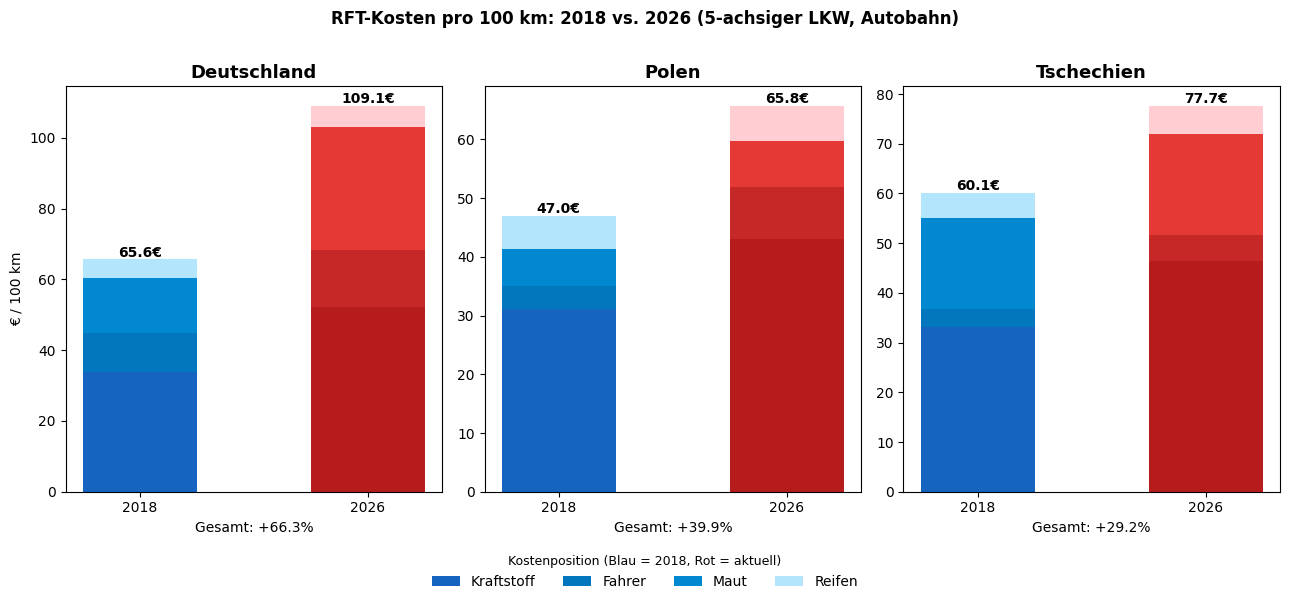

In [9]:
colors_2018    = ["#1565C0", "#0277BD", "#0288D1", "#B3E5FC"]
colors_current = ["#B71C1C", "#C62828", "#E53935", "#FFCDD2"]

fig, axes = plt.subplots(1, 3, figsize=(13, 6))
for ax, country in zip(axes, COUNTRIES):
    v18  = [data_2018[cat][country]    for cat in categories]
    vnow = [data_current[cat][country] for cat in categories]
    bottom_18 = bottom_now = 0
    for cat, v_18, v_now, c18, cnow in zip(categories, v18, vnow, colors_2018, colors_current):
        ax.bar(0, v_18,  0.5, bottom=bottom_18,  color=c18,  label=cat if country == "Germany" else "")
        ax.bar(1, v_now, 0.5, bottom=bottom_now, color=cnow)
        bottom_18  += v_18
        bottom_now += v_now
    total_18  = sum(v18)
    total_now = sum(vnow)
    ax.annotate(f"{total_18:.1f}€",  xy=(0, total_18),  ha="center", va="bottom", fontweight="bold", fontsize=10)
    ax.annotate(f"{total_now:.1f}€", xy=(1, total_now), ha="center", va="bottom", fontweight="bold", fontsize=10)
    ax.set_title(COUNTRY_LABELS[country], fontsize=13, fontweight="bold")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["2018", year])
    ax.set_ylabel("€ / 100 km" if country == "Germany" else "")
    chg = (total_now - total_18) / total_18 * 100
    ax.set_xlabel(f"Gesamt: {chg:+.1f}%", fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=10, frameon=False,
           title="Kostenposition (Blau = 2018, Rot = aktuell)", title_fontsize=9)
fig.suptitle(f"RFT-Kosten pro 100 km: 2018 vs. {year} (5-achsiger LKW, Autobahn)",
             fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0.08, 1, 0.97])
plt.savefig("ijal_cost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Interpretation

1. **Deutschland**: Der CO₂-Aufschlag auf die LKW-Maut (ab Dez. 2023) hat die Mautkosten mehr als verdoppelt und Deutschlands komparativen Nachteil gegenüber Polen weiter vergrößert.

2. **Polen**: Trotz annähernder Verdopplung des Mindestlohns bleibt Polen durch niedrige Kraftstoffpreise und geringe Maut der kostengünstigste Standort.

3. **Tschechien**: Entwicklung zwischen DE und PL — steigende Löhne, aber kein vergleichbarer Mautsprung.

### Einschränkungen
- Mindestlohn ≠ tatsächlicher Fahrerlohn (LKW-Fahrer verdienen typischerweise mehr)
- Mautkosten basieren auf einer Referenzstrecke je Land
- Reifenpreise sind Schätzwerte
- Wechselkursschwankungen (PLN, CZK) beeinflussen die €-Vergleichswerte